In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R
from few.trajectory.ode.flux import KerrEccEqFlux
import matplotlib.pyplot as plt
import numpy as np

# Dephasing fixed total duration

In [2]:
traj_1PA = EMRIInspiral(func=Trajectory1PAT1R)
traj_0PA = EMRIInspiral(func=KerrEccEqFlux)

In [3]:
m1 = 1e6       # primary mass [solar masses]
m2 = 6e2       # secondary mass [solar masses]

a  = 0.0       # primary spin chi1 (dimensionless)
chi2  = 0.0   # secondary spin
p0 = 30.0      # initial orbital separation [M]

dt = 1.   # time step [s]
T  = 4    # total duration [yr]

In [4]:
logm2Tab = np.linspace(-3, 3, 200)
m2Tab = 10**logm2Tab
nuTab = m1*m2Tab/(m1 + m2Tab)**2.

In [5]:
t1PA, p1PA, e1PA, x1PA, Phi_phi1PA, Phi_theta1PA, Phi_r1PA, deltaM1PA, deltachit1PA = traj_1PA(
    m1, m2,
    a,        # chi1 (primary spin)
    p0,
    0.0,      # e0: circular
    1.0,      # xI: equatorial prograde
    chi2,
    T=T,
    dt=dt,
    in_coordinate_time=False
)

t0PA, p0PA, e0PA, x0PA, Phi_phi0PA, Phi_theta0PA, Phi_r0PA = traj_0PA(
    m1, m2,
    a,        # chi1 (primary spin)
    p0,
    0.0,      # e0: circular
    1.0,      # xI: equatorial prograde
    T=T,
    dt=dt,
    in_coordinate_time=False
)

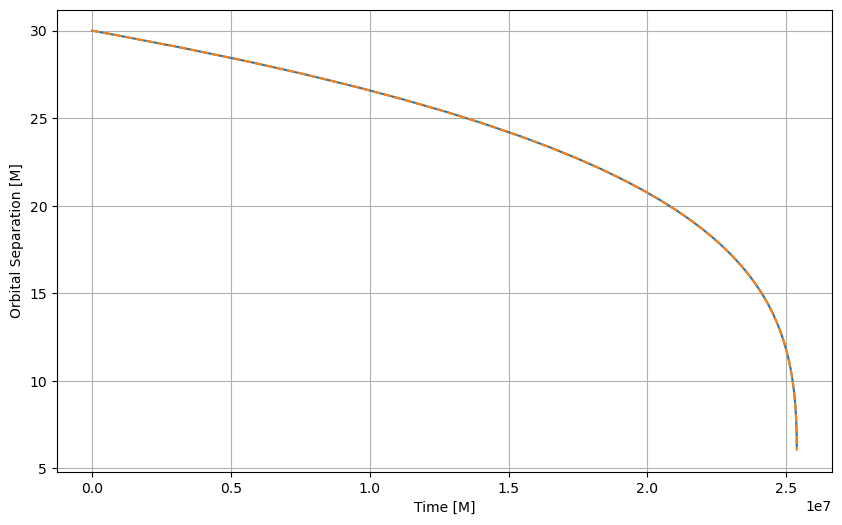

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(t1PA, p1PA, label="1PA")
plt.plot(t0PA, p0PA, label="0PA", linestyle="--")
plt.xlabel("Time [M]")
plt.ylabel("Orbital Separation [M]")
plt.grid()
plt.show()

In [7]:
dephasing = []
for m2 in m2Tab:
    t1PA, p1PA, e1PA, x1PA, Phi_phi1PA, Phi_theta1PA, Phi_r1PA, deltaM1PA, deltachit1PA = traj_1PA(
        m1, m2,
        a,        # chi1 (primary spin)
        p0,
        0.0,      # e0: circular
        1.0,      # xI: equatorial prograde
        chi2,
        T=T,
        dt=dt,
        in_coordinate_time=False
    )

    t0PA, p0PA, e0PA, x0PA, Phi_phi0PA, Phi_theta0PA, Phi_r0PA = traj_0PA(
        m1, m2,
        a,        # chi1 (primary spin)
        p0,
        0.0,      # e0: circular
        1.0,      # xI: equatorial prograde
        T=T,
        dt=dt,
        in_coordinate_time=False
    )

    dephasing.append(np.abs(Phi_phi1PA[-1] - Phi_phi0PA[-1]))


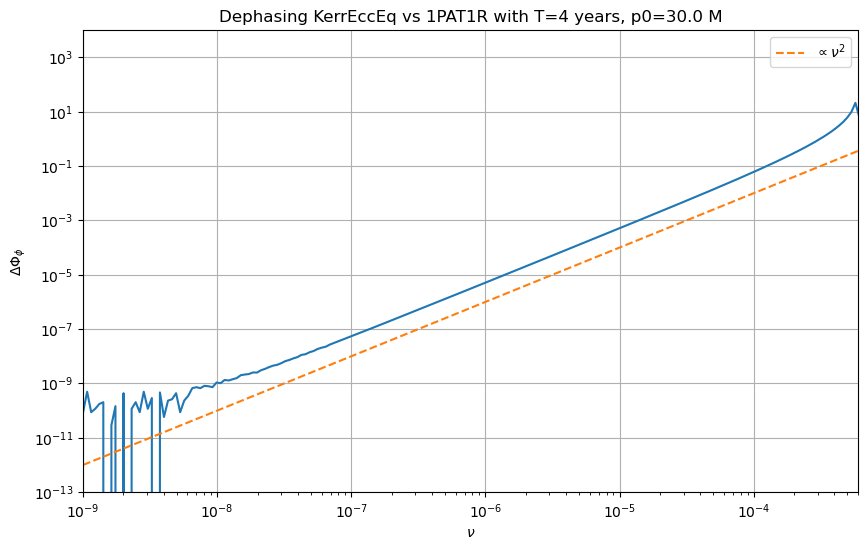

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(nuTab, dephasing)
plt.plot(nuTab,1e6 * nuTab**(2.), linestyle='--', label=r"$\propto \nu^2$")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\nu$")
plt.ylabel(r"$\Delta \Phi_{\phi}$")
plt.ylim(1e-13,1e4)
plt.xlim(1e-9,6e-4)
plt.title("Dephasing KerrEccEq vs 1PAT1R with T={} years, p0={} M".format(T, p0))
plt.grid()
plt.legend()
plt.show()

# Dephasing fixed total duration

In [13]:
traj_1PA = EMRIInspiral(func=Trajectory1PAT1R)
traj_0PA = EMRIInspiral(func=KerrEccEqFlux)

In [34]:
m1 = 1e6       # primary mass [solar masses]
m2 = 1e0       # secondary mass [solar masses]
nu = m1*m2/(m1 + m2)**2.

a  = 0.0       # primary spin chi1 (dimensionless)
chi2  = 0.0   # secondary spin
p0 = 8.0      # initial orbital separation [M]

dt = 1.   # time step [s]
TTab  = np.linspace(1e-3, 4, 100)    # total duration [yr]

In [35]:
dephasing = []
for T in TTab:
    t1PA, p1PA, e1PA, x1PA, Phi_phi1PA, Phi_theta1PA, Phi_r1PA, deltaM1PA, deltachit1PA = traj_1PA(
        m1, m2,
        a,        # chi1 (primary spin)
        p0,
        0.0,      # e0: circular
        1.0,      # xI: equatorial prograde
        chi2,
        T=T,
        dt=dt,
        in_coordinate_time=False
    )

    t0PA, p0PA, e0PA, x0PA, Phi_phi0PA, Phi_theta0PA, Phi_r0PA = traj_0PA(
        m1, m2,
        a,        # chi1 (primary spin)
        p0,
        0.0,      # e0: circular
        1.0,      # xI: equatorial prograde
        T=T,
        dt=dt,
        in_coordinate_time=False
    )

    dephasing.append(np.abs(Phi_phi1PA[-1] - Phi_phi0PA[-1]))


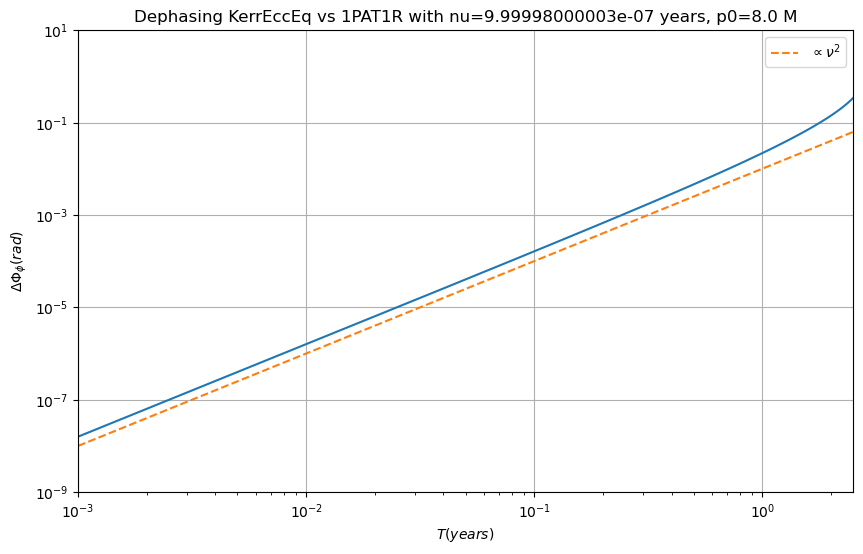

In [42]:
plt.figure(figsize=(10, 6))
plt.plot(TTab, dephasing)
plt.plot(TTab,1e-2 * TTab**(2.), linestyle='--', label=r"$\propto \nu^2$")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$T (years)$")
plt.ylabel(r"$\Delta \Phi_{\phi} (rad)$")
plt.ylim(1e-9,1e1)
plt.xlim(1e-3,2.5)
plt.title("Dephasing KerrEccEq vs 1PAT1R with nu={} years, p0={} M".format(nu, p0))
plt.grid()
plt.legend()
plt.show()

In [26]:
p0PA

array([10.        ,  9.99930881,  9.99515767,  9.97010514,  9.81421441,
        9.58537413,  9.48794388])